# IMPORT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# READ DATA

In [ ]:
import pandas as pd
data=pd.read_csv('/content/drive/MyDrive/heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# DATA PREPROCESSING

# MISSING VALUE

In [ ]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


# DUPLICATE VALUES

In [ ]:
data.duplicated().sum()

np.int64(0)

# REMOVE UNWANTED COLUMNS

In [ ]:
print(data.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


# KNN MODEL

# ONE-HOT ENCODING

In [ ]:
x_encoded = pd.get_dummies(x, columns=['ST_Slope'], drop_first=True)
display(x_encoded.head())

,Flat,Up
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True


# SPLIT TRAIN AND TEST (after encoding)

In [ ]:
from sklearn.model_selection import train_test_split
xtrain_encoded, xtest_encoded, ytrain, ytest = train_test_split(x_encoded, y, test_size=0.3, random_state=42)

# Check data types in y

In [ ]:
display(y.dtypes)

,0
Age,int64
Sex,object
ChestPainType,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

# READ DATA (assuming the file path is correct)
data = pd.read_csv('/content/gdrive/MyDrive/heart.csv')

# DATAPREPROCESSING
# MISSING VALUE (assuming there are no missing values based on previous output)
# data.isnull().sum()

# DUPLICATE VALUES (assuming there are no duplicate values based on previous output)
# data.duplicated().sum()

# REMOVE UNWANTED COLUMNS (assuming 'Oldpeak' is still the column to drop)
data = data.drop('Oldpeak', axis=1)

print(data.head())

# Categorical to Numeric
# Use get_dummies for one-hot encoding of categorical features
data = pd.get_dummies(data, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

# Display the first few (optional)
# print(data.head())

# Split input and output
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split Train and Test
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42) # Added random_state for reproducibility

# KNN Model
# Import KNeighborsClassifier (already imported above)

# Instantiate and train a KNN model
knn = KNeighborsClassifier(n_neighbors=5) # You can choose a different number of neighbors
knn.fit(xtrain, ytrain)

# Make predictions on the test data
ypred = knn.predict(xtest)

# Calculate accuracy using the imported metrics module and the predicted values
accuracy = metrics.accuracy_score(ytest, ypred)
print(f"KNN Accuracy: {accuracy}") # Added a descriptive print statement

# You can also add the confusion matrix plotting here if desired
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(ytest, ypred)
# plt.figure(figsize=(10, 10))
# sns.heatmap(cm, annot=True)
# plt.title('KNN Confusion Matrix')
# plt.show()

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina ST_Slope  HeartDisease  
0              N       Up             0  
1              N     Flat             1  
2              N       Up             0  
3              Y     Flat             1  
4              N       Up             0  
KNN Accuracy: 0.6159420289855072


In [ ]:
ypred=knn.predict(xtest)


In [ ]:
knn.fit(xtrain,ytrain)

KNeighborsClassifier()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

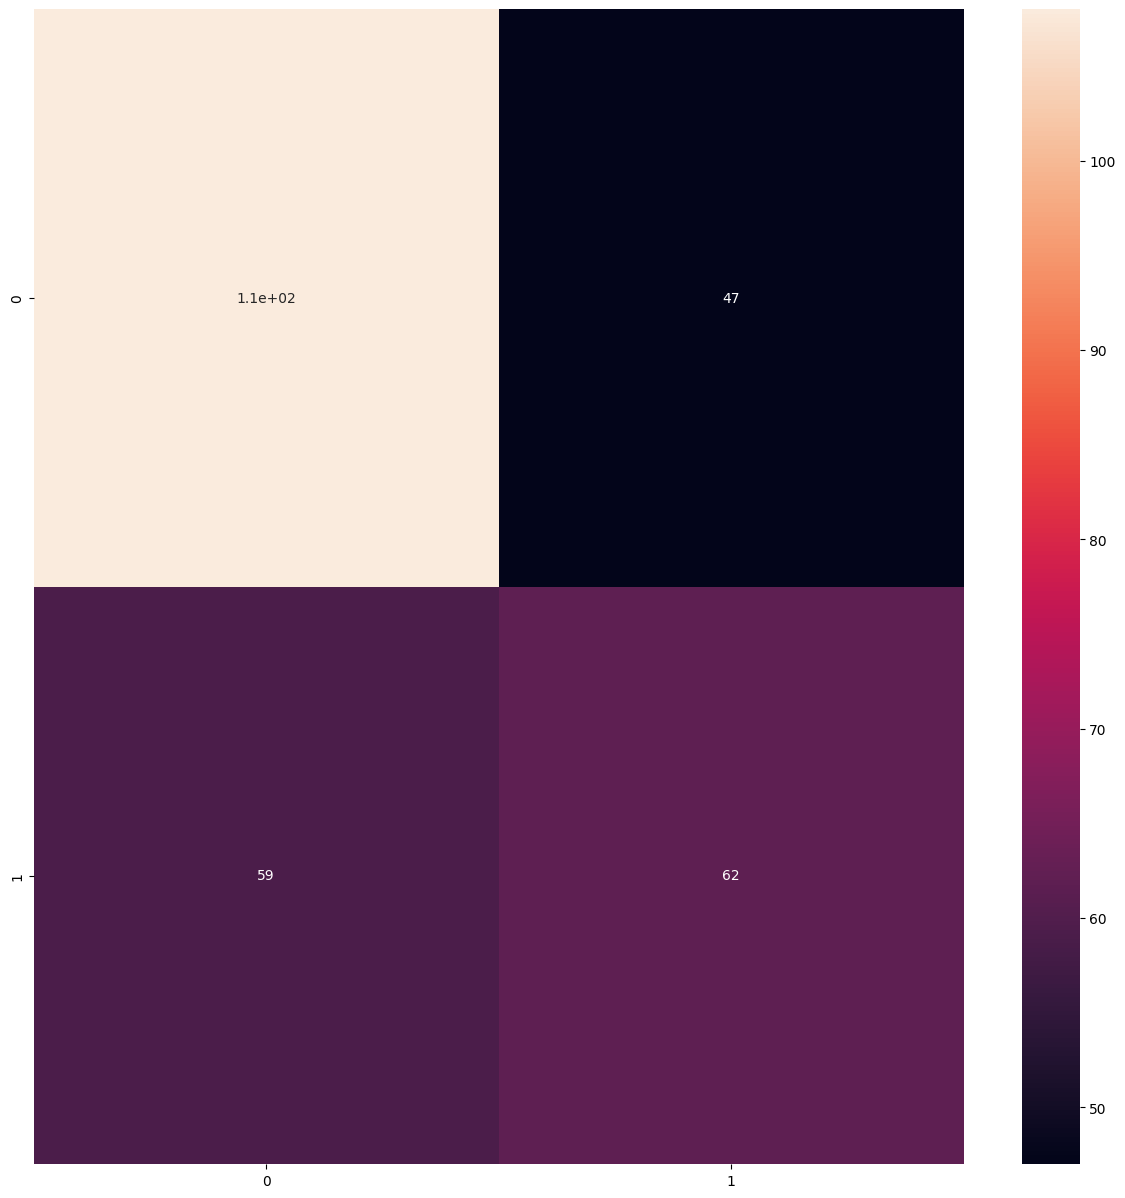

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest,ypred)
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True)

# SVM Model

In [ ]:
from sklearn.svm import SVC
svm=SVC(kernel='linear')
svm.fit(xtrain,ytrain)

SVC(kernel='linear')

In [ ]:
svmypred=svm.predict(xtest)

<Axes: >

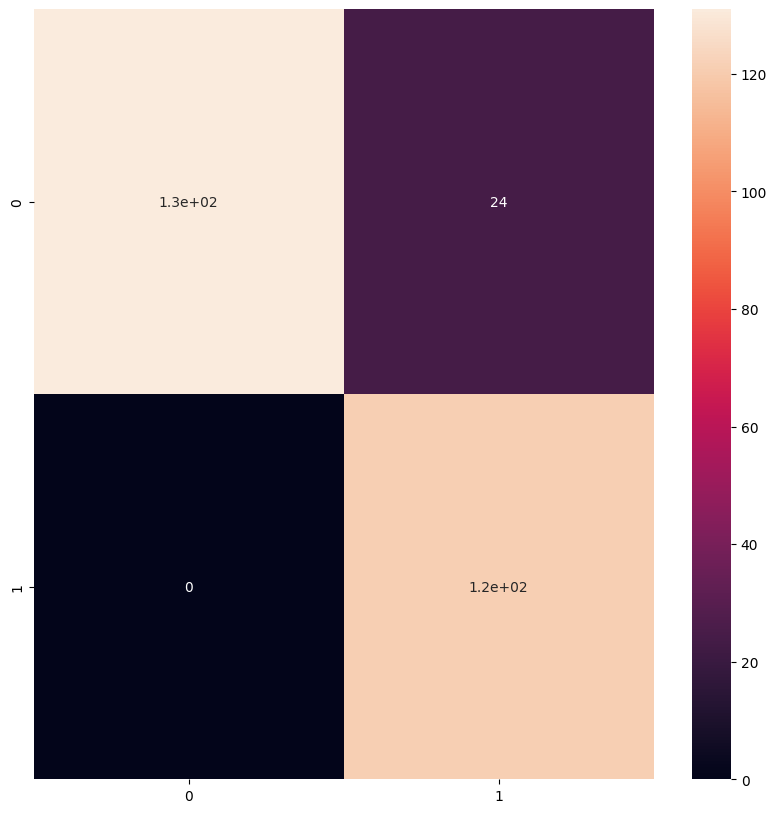

In [ ]:
from sklearn.metrics import confusion_matrix
svmcm=confusion_matrix(ytest,svmypred)
plt.figure(figsize=(10,10))
sns.heatmap(svmcm,annot=True)

In [ ]:
from sklearn.metrics import accuracy_score
svmaccuracy=accuracy_score(ytest,svmypred)
svmaccuracy

0.9130434782608695

# RANDOM FOREST

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train and y_train are pandas DataFrames or Series
# Example data (replace with your actual data)
data = {'feature1': ['1', '2', 'M', '4'], 'target': ['0', '1', '0', '1']}
df = pd.DataFrame(data)
X_train = df[['feature1']]
y_train = df['target']

# Replace 'M' with NaN
X_train = X_train.replace('M', np.nan)

# Convert to numeric and handle missing values
X_train['feature1'] = pd.to_numeric(X_train['feature1'])
X_train = X_train.fillna(X_train['feature1'].mean())  # Impute with mean

# Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

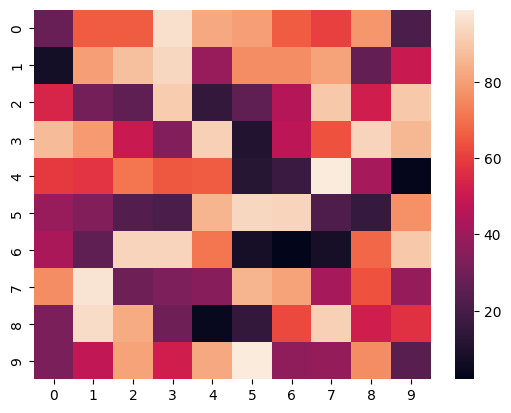

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generating a 10x10 matrix of random numbers
data = np.random.randint(1, 100, (10, 10))

sns.heatmap(data)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
rfaccuracy=accuracy_score(ytest,rfypred)
rfaccuracy

0.9202898550724637

# SAVE BEST MODEL

In [ ]:
import joblib

In [ ]:
joblib.dump(svm,'/content/finalmodel.pk')

['/content/finalmodel.pk']

In [ ]:
import numpy as np
Label={
    0:'NO HEART DISEASE',
    1:'HEART DISEASE',
}
sample_input=np.array([[6,5,3,2,5,1,2]])

print(sample_input)

[[6 5 3 2 5 1 2]]
